# Decision Tree

In [1]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

/net/cremi/maxguillon/Bureau/espaces/travail/S3/AAA/projet/CodeCloneValidation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

## Vectoriasation du dataset

In [3]:
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

In [4]:
X_train_text = df_train['func1'] + " [SEP] " + df_train['func2']
X_test_text = df_test['func1'] + " [SEP] " + df_test['func2']

y_train = df_train['label']
y_test = df_test['label']

In [5]:
del df_train, df_test

In [6]:
tfidf = TfidfVectorizer(max_features=100000, stop_words='english')

In [7]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

## Entrainement arbre de décision

In [ ]:
clf = DecisionTreeClassifier(
    max_depth=50,       # Important pour éviter le surapprentissage et réduire le temps
    random_state=42,
    min_samples_leaf=5,  # Lisse un peu le modèle
    class_weight='balanced'
)

In [9]:
clf.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## Evaluation

In [10]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

## Interprétation des résultats

In [23]:
train_acc = clf.score(X_train, y_train)

print(f"Accuracy Train : {train_acc:.4f}")
print(f"Accuracy Test  : {acc:.4f}")

# Calcul de l'écart (Gap)
gap = train_acc - acc
print(f"Ecart : {gap:.4f}")

Accuracy Train : 0.9949
Accuracy Test  : 0.9610
Ecart : 0.0340


On constate une accuracy de 99% sur les données d'entrainment et 95% sur les données de test. Cela montre que notre modéle généralise bien.

In [24]:
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    358596
        True       0.82      0.91      0.86     56820

    accuracy                           0.96    415416
   macro avg       0.90      0.94      0.92    415416
weighted avg       0.96      0.96      0.96    415416



On constate un recall de 92%, cela veut dire que notre modéle détecte 92% des clones présents. Le pont faible de notre modéle est la précision, seulement 81% ce qui veux dore que quand notre modéle dit détécter un clone, ils se trompe 1 fois sur 5 (19% de faux positifs).

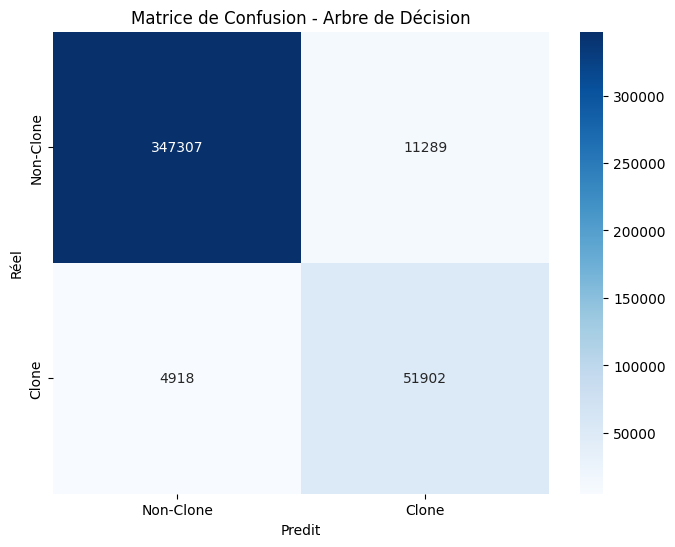

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Clone', 'Clone'], 
            yticklabels=['Non-Clone', 'Clone'])
plt.xlabel('Predit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Arbre de Décision')
plt.show()

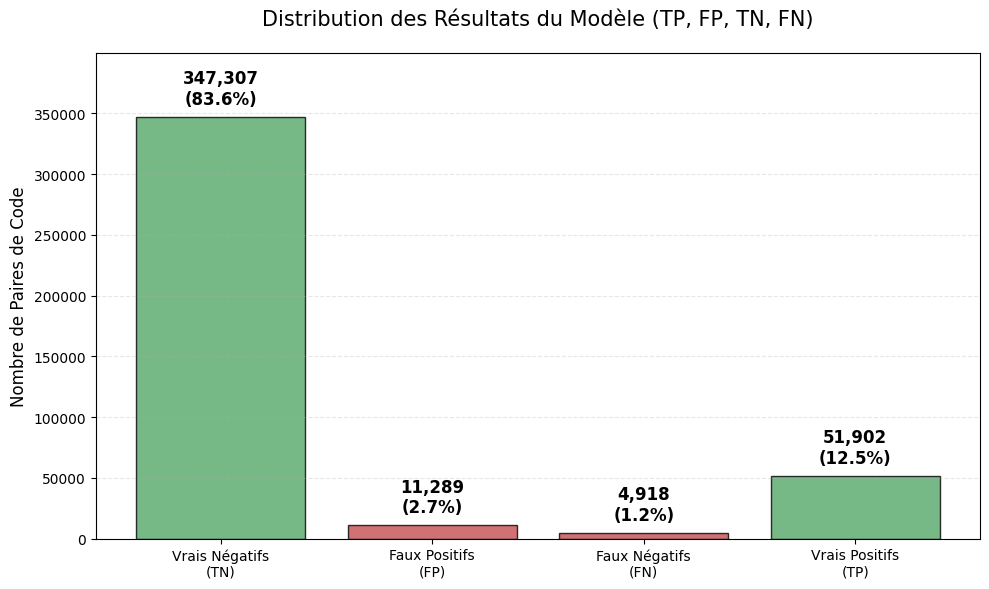

Total des erreurs (FP + FN) : 16207 sur 415416 exemples.
Le modèle a généré 11289 fausses alertes (Faux Positifs).
Le modèle a manqué 4918 clones réels (Faux Négatifs).


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Calcul de la matrice de confusion
# cm[0,0]: TN, cm[0,1]: FP, cm[1,0]: FN, cm[1,1]: TP
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 2. Préparation des données pour le graphique
categories = ['Vrais Négatifs\n(TN)', 'Faux Positifs\n(FP)', 
              'Faux Négatifs\n(FN)', 'Vrais Positifs\n(TP)']
counts = [tn, fp, fn, tp]
# Couleurs : Vert pour les bonnes prédictions, Rouge pour les erreurs
colors = ['#55a868', '#c44e52', '#c44e52', '#55a868'] 

# 3. Création du diagramme en barres
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, edgecolor='black', alpha=0.8)

# 4. Ajout des pourcentages et des valeurs
total = sum(counts)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height + (max(counts)*0.02), 
             f'{int(height):,}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Esthétique
plt.title('Distribution des Résultats du Modèle (TP, FP, TN, FN)', fontsize=15, pad=20)
plt.ylabel('Nombre de Paires de Code', fontsize=12)
plt.ylim(0, max(counts) * 1.15) # Marge au-dessus
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Affichage
plt.tight_layout()
plt.show()

# --- Analyse Textuelle ---
print(f"Total des erreurs (FP + FN) : {fp + fn} sur {total} exemples.")
print(f"Le modèle a généré {fp} fausses alertes (Faux Positifs).")
print(f"Le modèle a manqué {fn} clones réels (Faux Négatifs).")

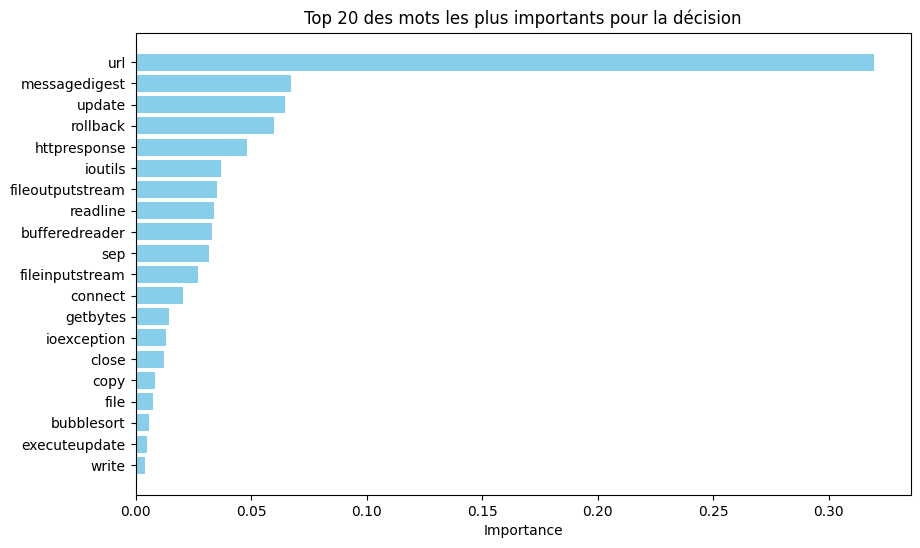

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer les scores d'importance et les mots
importances = clf.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Créer un DataFrame pour trier
feature_importance_df = pd.DataFrame({'word': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['word'], feature_importance_df['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 20 des mots les plus importants pour la décision")
plt.xlabel("Importance")
plt.show()

Cette analyse montre les principales features (top 20) sur lesquelles s'appuie l’arbre de décision.